In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [1]:
from huggingface_hub import hf_hub_download
import os

# Descargar el checkpoint oficial de SAM 3
#checkpoint_path = hf_hub_download(
#    repo_id="facebook/sam3", 
#    filename="sam3.pt"
#)

checkpoint_path = os.path.abspath("sam3.pt")
print("Checkpoint de SAM 3 descargado con éxito en:", checkpoint_path)

Checkpoint de SAM 3 descargado con éxito en: c:\Users\dksfd\roboFut\sam3.pt


Resolución del video: 540x480 píxeles


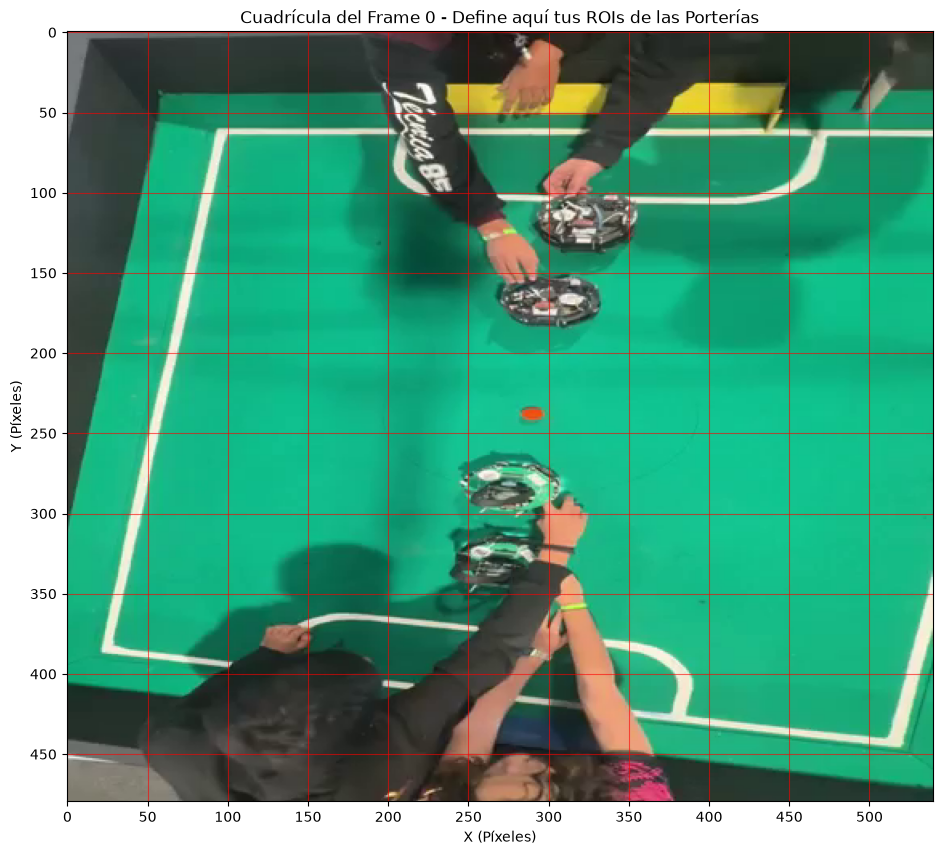

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

video_path = "robot_video.mp4"

# (Frame 0)
cap = cv2.VideoCapture(video_path)
ret, frame0 = cap.read()
cap.release()

if ret:
    frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
    h, w, _ = frame0.shape
    print(f"Resolución del video: {w}x{h} píxeles")
    
    # Graficar con cuadrícula visible y marcas cada 50 píxeles
    plt.figure(figsize=(12, 10))
    plt.imshow(frame0_rgb)
    plt.grid(True, color='red', alpha=0.6, linestyle='-')
    
    plt.xticks(np.arange(0, w, 50))
    plt.yticks(np.arange(0, h, 50))
    
    plt.title("Cuadrícula del Frame 0 - Define aquí tus ROIs de las Porterías")
    plt.xlabel("X (Píxeles)")
    plt.ylabel("Y (Píxeles)")
    plt.show()
else:
    print("Error: No se pudo abrir el video. Asegúrate de que 'robot_video.mp4' esté en la misma carpeta.")

In [ ]:
from ultralytics.models.sam import SAM3VideoSemanticPredictor
import torch
import cv2
import numpy as np
import supervision as sv

import importlib
import soccer_tracker
importlib.reload(soccer_tracker)
from soccer_tracker import SoccerTracker

video_path = "robot_video.mp4" 
output_video_path = "cancha_robot_tracking_sam3.mp4"

# None = video completo.
max_frames = None 

# 10 = debug,
# None = frames originales.
target_fps = None

# Límites [xmin, ymin, xmax, ymax]
# Frame 0
yellow_goal_roi = [210, 25, 440, 60]       # Portería superior (Amarilla)
blue_goal_roi = [150, 425, 350, 450]     # Portería inferior (Azul)

# cm por píxel
cm_per_pixel = 0.364 
 
possession_threshold = 45.0 

cap = cv2.VideoCapture(video_path)
orig_fps = cap.get(cv2.CAP_PROP_FPS)
if not orig_fps or orig_fps == 0:
    orig_fps = 30.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

if target_fps is not None and target_fps < orig_fps:
    vid_stride = max(1, int(round(orig_fps / target_fps)))
    effective_fps = orig_fps / vid_stride
else:
    vid_stride = 1
    effective_fps = orig_fps

print(f"FPS Original: {orig_fps:.2f} | Vid Stride (Salto): {vid_stride} | FPS Efectivo: {effective_fps:.2f}")

# centros verticales de porterías para asignación de equipos
yellow_center_y = (yellow_goal_roi[1] + yellow_goal_roi[3]) / 2.0
blue_center_y = (blue_goal_roi[1] + blue_goal_roi[3]) / 2.0

# SAM 3
overrides = dict(
    conf=0.40, 
    task="segment", 
    mode="predict", 
    model=checkpoint_path,
    vid_stride=vid_stride
)
if torch.cuda.is_available():
    overrides["half"] = True

video_predictor = SAM3VideoSemanticPredictor(overrides=overrides)

# predicción en streaming
resultados_video = video_predictor(
    source=video_path,
    text=["red ball", "robot"],
    stream=True
)

writer = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*"mp4v"), effective_fps, (w, h)
)

soccer_tracker = SoccerTracker(
    fps=effective_fps,
    cm_per_pixel=cm_per_pixel,
    possession_threshold=possession_threshold,
    yellow_goal_roi=yellow_goal_roi,
    blue_goal_roi=blue_goal_roi,
    team_mapping={} # Se llena dinámicamente según la detección y tracking
)

print("Procesando video SAM 3 (Texto)...")
for idx, res in enumerate(resultados_video):
    # Control del límite de frames para pruebas rápidas
    if max_frames is not None and idx >= max_frames:
        print(f"({max_frames}) | max frames Finalizando...")
        break
        
    frame = res.orig_img
    det = sv.Detections.from_ultralytics(res)
    
    ball_box = None
    robot_boxes_dict = {}
    masks_dict = {}
    
    if len(det) > 0:
        for i in range(len(det)):
            # bounding boxes de [xmin, ymin, xmax, ymax] a [x, y, w, h]
            xmin, ymin, xmax, ymax = det.xyxy[i]
            box = [xmin, ymin, xmax - xmin, ymax - ymin]
            
            cls_id = det.class_id[i]
            track_id = int(det.tracker_id[i]) if det.tracker_id is not None else i
            
            # class_id 0 = "red ball", class_id 1 = "robot"
            if cls_id == 0:
                ball_box = box
            elif cls_id == 1:
                box_area = (xmax - xmin) * (ymax - ymin)

                if box_area > 1500 and box_area < 3500:  # Ajusta estos valores
                    robot_boxes_dict[track_id] = box
                    masks_dict[track_id] = det.mask[i] if det.mask is not None else None
                
                    # Mapear el equipo, primera vez
                    if track_id not in soccer_tracker.team_mapping:
                        # Centro
                        ry = ymin + (ymax - ymin) / 2.0
                        
                        # distancias a las porterías
                        dist_to_yellow = abs(ry - yellow_center_y)
                        dist_to_blue = abs(ry - blue_center_y)
                        
                        # Asignar equipo por la porteria mas cercana
                        if dist_to_yellow < dist_to_blue:
                            team_name = "Robot Yellow"
                        else:
                            team_name = "Robot Blue"
                            
                        soccer_tracker.team_mapping[track_id] = f"{team_name} {track_id}"
                    
    # Actualizar
    soccer_tracker.update(idx, ball_box, robot_boxes_dict)
    annotated = soccer_tracker.annotate_frame(frame, ball_box, robot_boxes_dict, masks_dict)
    writer.write(annotated)

writer.release()
print(f"Video guardado: {output_video_path}")

FPS Original: 30.00 | Vid Stride (Salto): 1 | FPS Efectivo: 30.00
Procesando video SAM 3 (Texto)...

Ultralytics 8.4.66  Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
video 1/1 (frame 1/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 4 robots, 7821.8ms
video 1/1 (frame 2/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 4 robots, 5194.9ms
video 1/1 (frame 3/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 4278.1ms
video 1/1 (frame 4/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 4334.9ms
video 1/1 (frame 5/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 3739.6ms
video 1/1 (frame 6/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 3624.2ms
video 1/1 (frame 7/4101) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 


             ESTADÍSTICAS DEL PARTIDO          
Marcador Final:
  Equipo Amarillo: 9 goles
  Equipo Azul: 5 goles

Historial y Minuto de Goles:
  1. Gol de Team Blue en el segundo 2.43 (Frame 73)
  2. Gol de Team Yellow en el segundo 15.67 (Frame 470)
  3. Gol de Team Blue en el segundo 68.23 (Frame 2047)
  4. Gol de Team Blue en el segundo 78.30 (Frame 2349)
  5. Gol de Team Blue en el segundo 81.20 (Frame 2436)
  6. Gol de Team Yellow en el segundo 91.40 (Frame 2742)
  7. Gol de Team Yellow en el segundo 96.10 (Frame 2883)
  8. Gol de Team Yellow en el segundo 99.00 (Frame 2970)
  9. Gol de Team Yellow en el segundo 102.80 (Frame 3084)
  10. Gol de Team Yellow en el segundo 107.47 (Frame 3224)
  11. Gol de Team Yellow en el segundo 114.70 (Frame 3441)
  12. Gol de Team Yellow en el segundo 119.80 (Frame 3594)
  13. Gol de Team Yellow en el segundo 122.67 (Frame 3680)
  14. Gol de Team Blue en el segundo 130.93 (Frame 3928)

Tiempo de Posesión de Balón:
  - Team Yellow: 17.37 segundo

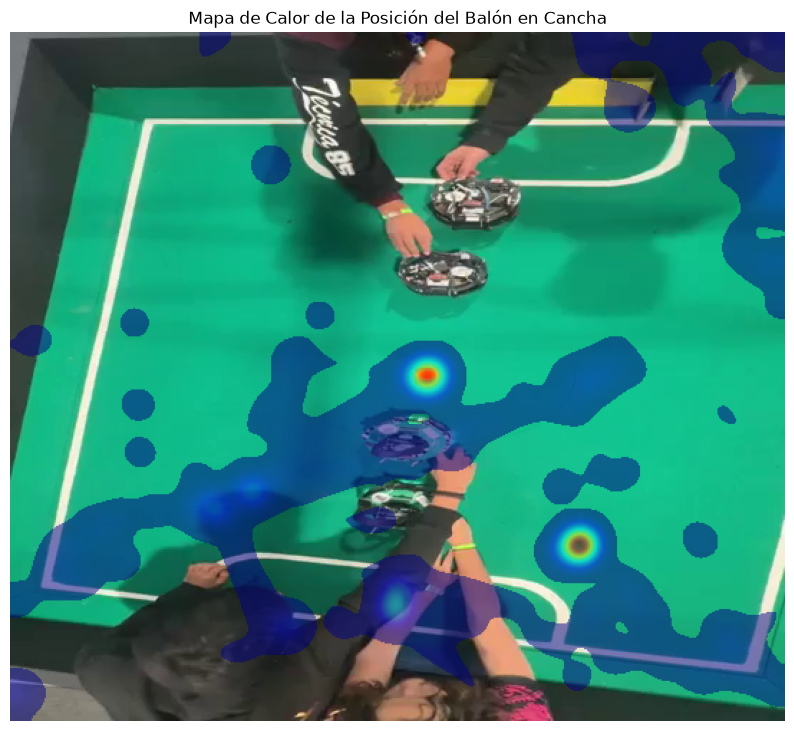

In [ ]:
import matplotlib.pyplot as plt

stats = soccer_tracker.get_statistics()

print("\n==============================================")
print("             ESTADÍSTICAS DEL PARTIDO          ")
print("==============================================")
print(f"Marcador Final:")
print(f"  Equipo Amarillo: {stats['final_score']['Team Yellow']} goles")
print(f"  Equipo Azul: {stats['final_score']['Team Blue']} goles")

print("\nHistorial y Minuto de Goles:")
for i, g in enumerate(stats['goals'], 1):
    print(f"  {i}. Gol de {g['team']} en el segundo {g['time']:.2f} (Frame {g['frame']})")

print("\nTiempo de Posesión de Balón:")
for team, sec in stats['possession_seconds'].items():
    pct = stats['possession_percentage'][team]
    print(f"  - {team}: {sec:.2f} segundos ({pct:.1f}%)")

print("\nRendimiento de Velocidad de los Robots:")
for obj_id, data in stats['robot_speeds'].items():
    print(f"  - {data['team']} (ID {obj_id}):")
    print(f"    * Velocidad Promedio: {data['avg_speed']:.2f} cm/s")
    print(f"    * Velocidad Máxima: {data['max_speed']:.2f} cm/s")
print("==============================================\n")

# Mapa de Calor 
cap = cv2.VideoCapture(video_path)
ret, frame0 = cap.read()
cap.release()

if ret:
    heatmap_cancha = soccer_tracker.generate_heatmap(frame0, kernel_size=51, alpha=0.5)
    cv2.imwrite("heatmap_pelota.png", heatmap_cancha)

    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(heatmap_cancha, cv2.COLOR_BGR2RGB))
    plt.title("Mapa de Calor de la Posición del Balón en Cancha")
    plt.axis('off')
    plt.show()
else:
    print("Sin frame0")